In [1]:
import os
import pandas as pd
import sqlite3

os.chdir(r'E:\Job\Project\Clinical-trial-enrollment')
conn = sqlite3.connect('clinical_trial.db')

# ── Query 1: Enrollment by Phase ──────────────────────
q1 = pd.read_sql("""
    SELECT phase,
           COUNT(*) AS trial_count,
           ROUND(AVG(enrollment),0) AS avg_enrollment,
           ROUND(AVG(duration_months),1) AS avg_duration_months
    FROM trials
    WHERE enrollment > 0
    GROUP BY phase
    ORDER BY avg_enrollment DESC
""", conn)

print(q1.to_string(index=False))

    phase  trial_count  avg_enrollment  avg_duration_months
  Phase 3         1517           639.0                 28.5
Phase 2/3          182           163.0                 33.7
  Phase 2         1192           136.0                 26.8
Phase 1/2          234            86.0                 34.3


In [2]:
# ── Query 2: Duration by Funder Type ──────────────────
q2 = pd.read_sql("""
    SELECT funder_type,
           COUNT(*) AS trial_count,
           ROUND(AVG(enrollment),0) AS avg_enrollment,
           ROUND(AVG(duration_months),1) AS avg_duration_months
    FROM trials
    WHERE duration_months > 0
    GROUP BY funder_type
    ORDER BY avg_duration_months
""", conn)

print(q2.to_string(index=False))

funder_type  trial_count  avg_enrollment  avg_duration_months
   INDUSTRY         1157           402.0                 20.8
        FED           13           167.0                 35.9
      OTHER          637           212.0                 38.6
  OTHER_GOV           18            88.0                 39.4
    NETWORK            2           184.0                 56.5
        NIH           57           417.0                 67.0
      INDIV            6          1107.0                 71.5


In [3]:
# ── Query 3: Top 15 Countries ─────────────────────────
q3 = pd.read_sql("""
    SELECT country,
           COUNT(DISTINCT nct_number) AS trial_count,
           ROUND(AVG(enrollment),0) AS avg_enrollment
    FROM trial_countries
    WHERE country != ''
    GROUP BY country
    ORDER BY trial_count DESC
    LIMIT 15
""", conn)

print(q3.to_string(index=False))

       country  trial_count  avg_enrollment
 United States         1481           490.0
        Canada          497           912.0
       Germany          493           891.0
United Kingdom          333          1205.0
        Mexico          331          1159.0
         Spain          307          1203.0
        Poland          307          1204.0
         Italy          280          1194.0
        Russia          271          1309.0
         Japan          259           862.0
        France          253          1102.0
       Hungary          240          1285.0
         India          232          1222.0
   South Korea          216          1270.0
   Puerto Rico          215          1036.0


In [4]:
# ── Query 4: Enrollment Trend by Year ─────────────────
q4 = pd.read_sql("""
    SELECT start_year,
           COUNT(*) AS trials_started,
           ROUND(AVG(enrollment),0) AS avg_enrollment
    FROM trials
    WHERE start_year BETWEEN 2000 AND 2017
      AND enrollment > 0
    GROUP BY start_year
    ORDER BY start_year
""", conn)

print(q4.to_string(index=False))

 start_year  trials_started  avg_enrollment
     2000.0              34           297.0
     2001.0              40          1102.0
     2002.0              60           350.0
     2003.0              83           537.0
     2004.0             107           495.0
     2005.0             151           309.0
     2006.0             172           320.0
     2007.0             164           428.0
     2008.0             191           285.0
     2009.0             179           290.0
     2010.0             184           422.0
     2011.0             141           288.0
     2012.0             141           211.0
     2013.0             115           305.0
     2014.0             108           175.0
     2015.0              81           210.0
     2016.0              60           100.0
     2017.0               2            12.0


In [5]:
# ── Query 5: Masking vs Enrollment ────────────────────
q5 = pd.read_sql("""
    SELECT masking,
           COUNT(*) AS trial_count,
           ROUND(AVG(enrollment),0) AS avg_enrollment,
           ROUND(AVG(duration_months),1) AS avg_duration_months
    FROM trials
    WHERE masking IS NOT NULL AND enrollment > 0
    GROUP BY masking
    ORDER BY avg_enrollment DESC
""", conn)
print("\n=== Masking Type vs Enrollment ===")
print(q5.to_string(index=False))


=== Masking Type vs Enrollment ===
                                                                masking  trial_count  avg_enrollment  avg_duration_months
QUADRUPLE (PARTICIPANT, CARE_PROVIDER, INVESTIGATOR, OUTCOMES_ASSESSOR)          644           500.0                 29.7
                                     DOUBLE (PARTICIPANT, INVESTIGATOR)          642           489.0                 23.1
                                                                 DOUBLE          191           484.0                 23.8
                  TRIPLE (PARTICIPANT, INVESTIGATOR, OUTCOMES_ASSESSOR)           93           475.0                 30.5
                                                  SINGLE (INVESTIGATOR)           23           418.0                 30.9
                                             SINGLE (OUTCOMES_ASSESSOR)           49           326.0                 37.9
                                                                   NONE         1080           277.0          

In [6]:
# ── Query 6: Multinational vs Single Country ──────────
q6 = pd.read_sql("""
    SELECT CASE WHEN is_multinational = 1
                THEN 'Multinational'
                ELSE 'Single Country' END AS scope,
           COUNT(*) AS trial_count,
           ROUND(AVG(enrollment),0) AS avg_enrollment,
           ROUND(AVG(duration_months),1) AS avg_duration_months,
           ROUND(AVG(country_count),1) AS avg_countries
    FROM trials
    WHERE enrollment > 0
    GROUP BY is_multinational
""", conn)
print("\n=== Multinational vs Single Country ===")
print(q6.to_string(index=False))


=== Multinational vs Single Country ===
         scope  trial_count  avg_enrollment  avg_duration_months  avg_countries
Single Country         2162           217.0                 29.5            0.9
 Multinational          963           740.0                 26.7            8.8


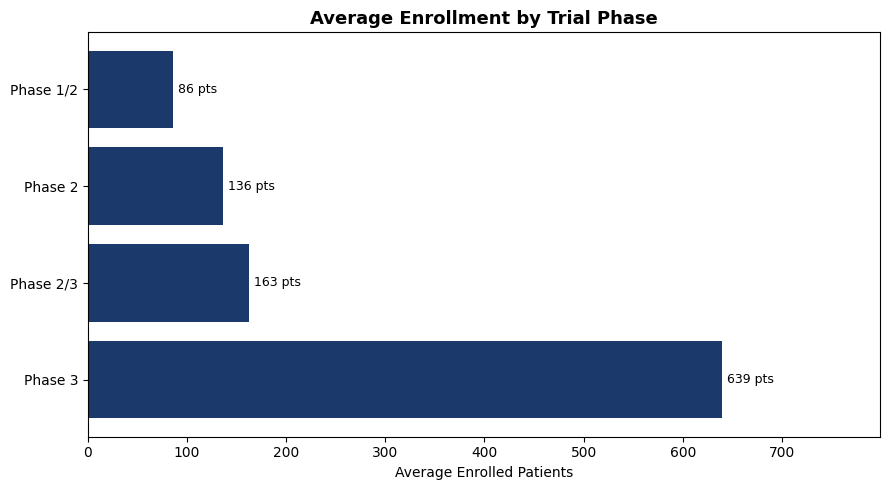

Chart 1 saved!


In [7]:
import matplotlib.pyplot as plt
from pathlib import Path
Path('outputs').mkdir(exist_ok=True)

# Chart 1 — Avg Enrollment by Phase
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(q1['phase'], q1['avg_enrollment'], color='#1B3A6B')
for bar, val in zip(bars, q1['avg_enrollment']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(val)} pts', va='center', fontsize=9)
ax.set_title('Average Enrollment by Trial Phase', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Enrolled Patients')
ax.set_xlim(0, q1['avg_enrollment'].max() * 1.25)
plt.tight_layout()
plt.savefig('outputs/01_enrollment_by_phase.png', dpi=150)
plt.show()
print('Chart 1 saved!')

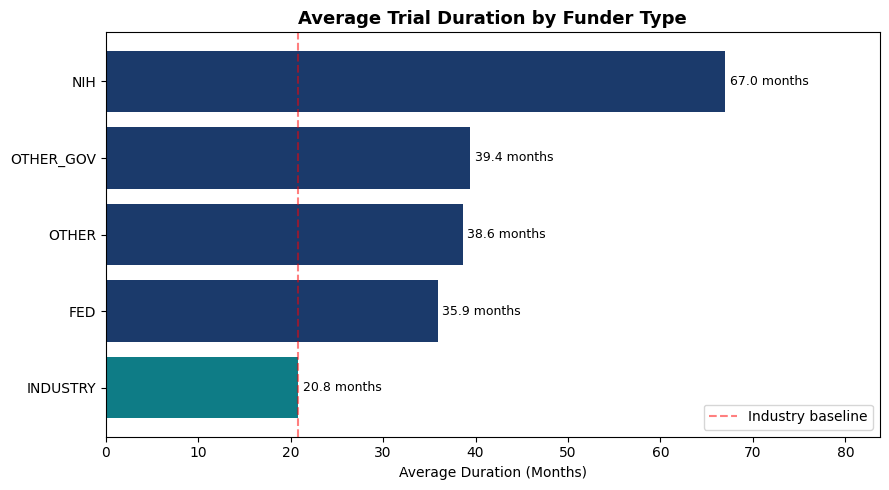

Chart 2 saved!


In [8]:
# Chart 2 — Duration by Funder Type
top_funders = q2[q2['trial_count'] >= 10]

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#0E7C86' if f == 'INDUSTRY' else '#1B3A6B' 
          for f in top_funders['funder_type']]
bars = ax.barh(top_funders['funder_type'], 
               top_funders['avg_duration_months'], color=colors)
for bar, val in zip(bars, top_funders['avg_duration_months']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val} months', va='center', fontsize=9)
ax.set_title('Average Trial Duration by Funder Type', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average Duration (Months)')
ax.set_xlim(0, top_funders['avg_duration_months'].max() * 1.25)
ax.axvline(x=top_funders[top_funders['funder_type']=='INDUSTRY']
           ['avg_duration_months'].values[0], 
           color='red', linestyle='--', alpha=0.5, label='Industry baseline')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/02_duration_by_funder.png', dpi=150)
plt.show()
print('Chart 2 saved!')

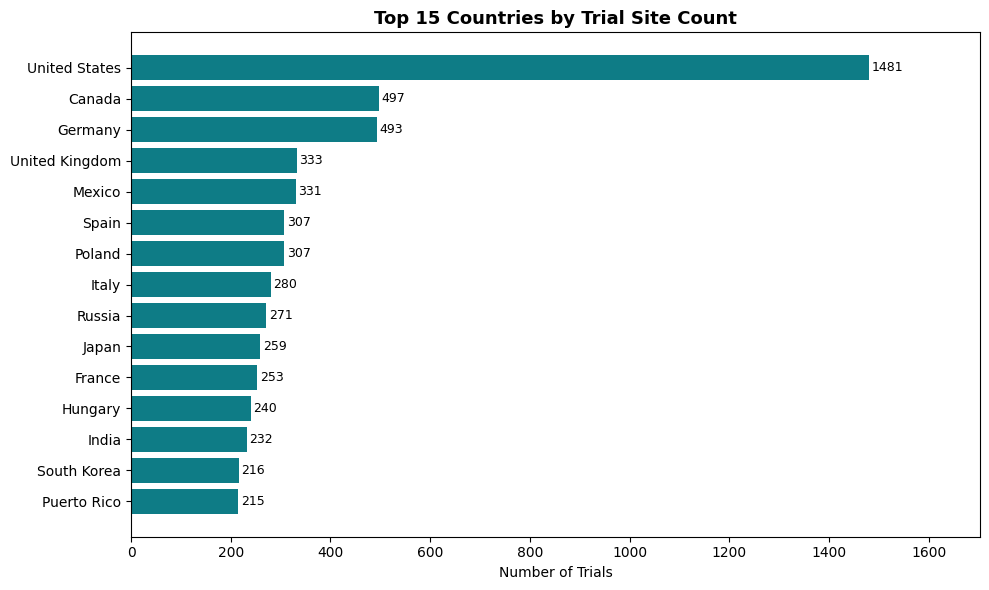

Chart 3 saved!


In [9]:
# Chart 3 — Top 15 Countries by Trial Count
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(q3['country'][::-1], q3['trial_count'][::-1], color='#0E7C86')
ax.set_title('Top 15 Countries by Trial Site Count', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Trials')
for i, (val, country) in enumerate(zip(q3['trial_count'][::-1], 
                                        q3['country'][::-1])):
    ax.text(val + 5, i, str(val), va='center', fontsize=9)
ax.set_xlim(0, q3['trial_count'].max() * 1.15)
plt.tight_layout()
plt.savefig('outputs/03_top_countries.png', dpi=150)
plt.show()
print('Chart 3 saved!')

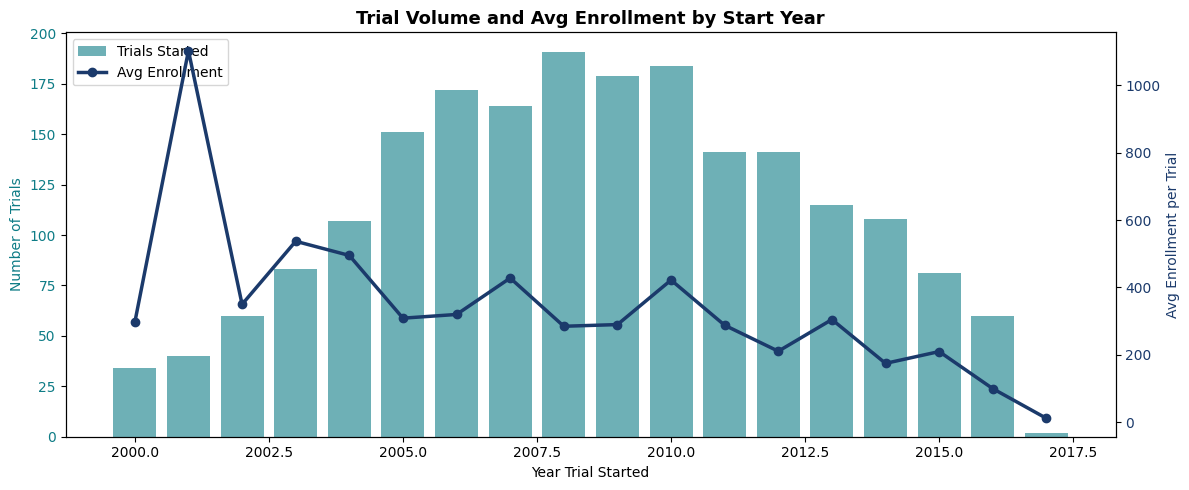

Chart 4 saved!


In [10]:
# Chart 4 — Enrollment Trend by Year
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(q4['start_year'], q4['trials_started'], 
        color='#0E7C86', alpha=0.6, label='Trials Started')
ax2.plot(q4['start_year'], q4['avg_enrollment'], 
         color='#1B3A6B', linewidth=2.5, marker='o', label='Avg Enrollment')

ax1.set_xlabel('Year Trial Started')
ax1.set_ylabel('Number of Trials', color='#0E7C86')
ax2.set_ylabel('Avg Enrollment per Trial', color='#1B3A6B')
ax1.set_title('Trial Volume and Avg Enrollment by Start Year', 
              fontsize=13, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#0E7C86')
ax2.tick_params(axis='y', labelcolor='#1B3A6B')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('outputs/04_enrollment_trend.png', dpi=150)
plt.show()
print('Chart 4 saved!')

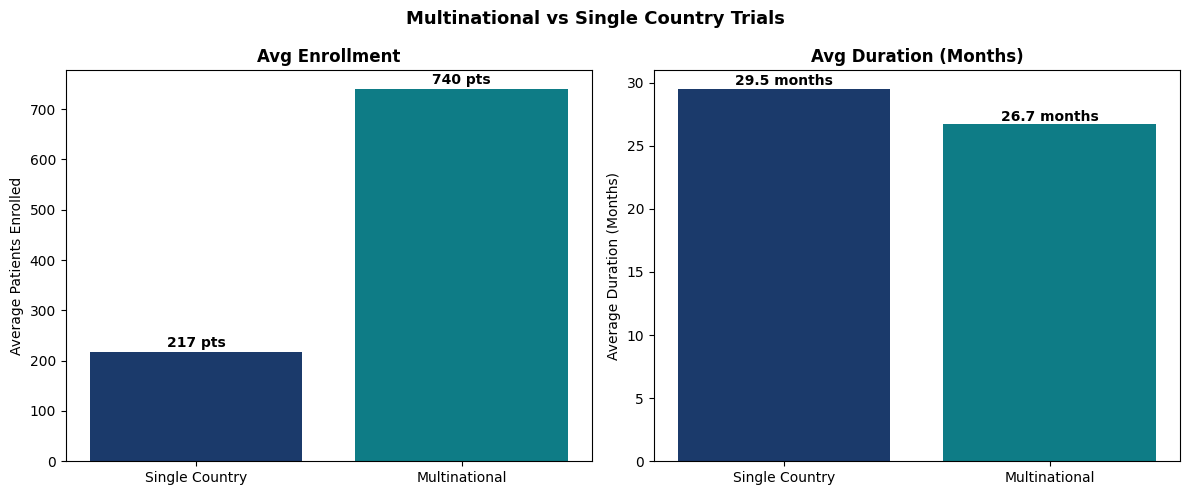

Chart 5 saved!


In [11]:
# Chart 5 — Multinational vs Single Country
q6 = pd.read_sql("""
    SELECT CASE WHEN is_multinational = 1
                THEN 'Multinational' ELSE 'Single Country' END AS scope,
           COUNT(*) AS trial_count,
           ROUND(AVG(enrollment),0) AS avg_enrollment,
           ROUND(AVG(duration_months),1) AS avg_duration_months
    FROM trials WHERE enrollment > 0
    GROUP BY is_multinational
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — Avg Enrollment
axes[0].bar(q6['scope'], q6['avg_enrollment'], 
            color=['#1B3A6B', '#0E7C86'])
for i, val in enumerate(q6['avg_enrollment']):
    axes[0].text(i, val + 10, f'{int(val)} pts', 
                 ha='center', fontweight='bold')
axes[0].set_title('Avg Enrollment', fontweight='bold')
axes[0].set_ylabel('Average Patients Enrolled')

# Right — Avg Duration
axes[1].bar(q6['scope'], q6['avg_duration_months'], 
            color=['#1B3A6B', '#0E7C86'])
for i, val in enumerate(q6['avg_duration_months']):
    axes[1].text(i, val + 0.3, f'{val} months', 
                 ha='center', fontweight='bold')
axes[1].set_title('Avg Duration (Months)', fontweight='bold')
axes[1].set_ylabel('Average Duration (Months)')

fig.suptitle('Multinational vs Single Country Trials', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/05_multinational_vs_single.png', dpi=150)
plt.show()
print('Chart 5 saved!')

In [1]:
import os
import pandas as pd
import sqlite3

os.chdir(r'E:\Job\Project\Clinical-trial-enrollment')
conn = sqlite3.connect('clinical_trial.db')

# Export for Power BI
pd.read_sql('SELECT * FROM trials', conn).to_csv('outputs/pbi_trials.csv', index=False)
pd.read_sql('SELECT * FROM trial_countries', conn).to_csv('outputs/pbi_countries.csv', index=False)

conn.close()
print('Done! Check outputs/ folder')  

Done! Check outputs/ folder


In [1]:
import os
import pandas as pd
import sqlite3

os.chdir(r'E:\Job\Project\Clinical-trial-enrollment')
conn = sqlite3.connect('clinical_trial.db')

df = pd.read_sql('SELECT * FROM trials', conn)

# Replace 0 and 1 with readable labels
df['scope'] = df['is_multinational'].map({1: 'Multinational', 0: 'Single Country'})

# Export updated file
df.to_csv('outputs/pbi_trials.csv', index=False)
conn.close()
print('Done! pbi_trials.csv updated with scope column')

Done! pbi_trials.csv updated with scope column
